In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#display first 5 rows
df = pd.read_csv('../data/bank.csv')
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:

print("Shape:", df.shape)                   #displays number of rows and columns
print("Columns:", df.columns.tolist())      #display names of all columns

Shape: (11162, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical:", numerical_cols)    #filtering the columns according to datatypes

Numerical: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical:", categorical_cols)   #filtering the Categorical according to datatypes

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].dtype}")
    #prints the column name with its data type helps us check the type of data in every column

age: int64
job: object
marital: object
education: object
default: object
balance: int64
housing: object
loan: object
contact: object
day: int64
month: object
duration: int64
campaign: int64
pdays: int64
previous: int64
poutcome: object
deposit: object


In [16]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [20]:
nulls = df.isnull().sum()
percentage = (nulls / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'Column': nulls.index,
    'Nulls': nulls.values,
    'Percentage': percentage.values
})
print(missing_table.to_string(index=False))

   Column  Nulls  Percentage
      age      0         0.0
      job      0         0.0
  marital      0         0.0
education      0         0.0
  default      0         0.0
  balance      0         0.0
  housing      0         0.0
     loan      0         0.0
  contact      0         0.0
      day      0         0.0
    month      0         0.0
 duration      0         0.0
 campaign      0         0.0
    pdays      0         0.0
 previous      0         0.0
 poutcome      0         0.0
  deposit      0         0.0


In [21]:
threshold = 0.6
df_drop_cols = df.dropna(thresh=int(threshold * len(df)), axis=1)

print("Before:", df.shape)
print("After: ", df_drop_cols.shape)
print("""
Why risky?
Dropping columns may remove important features even if they have
missing values. You permanently lose potentially valuable information.
""")

Before: (11162, 17)
After:  (11162, 17)

Why risky?
Dropping columns may remove important features even if they have
missing values. You permanently lose potentially valuable information.



In [ ]:
before = df.shape[0]
df_drop_rows = df.dropna()
after = df_drop_rows.shape[0]

print(f"Before: {before} rows")
print(f"After:  {after} rows")
print(f"Dropped: {before - after} rows")
print("""
explanation :
Use when missing rows are very few and removing them
won't significantly affect the dataset size.
""")

Before: 11162 rows
After:  11162 rows
Dropped: 0 rows

When to use?
Use when missing rows are very few and removing them
won't significantly affect the dataset size.



In [26]:
# Mean only
df_mean = df.copy()
for col in numerical_cols:
    df_mean[col] = df_mean[col].fillna(df[col].mean())
print("Nulls after Mean:", df_mean.isnull().sum().sum())

# Median only
df_median = df.copy()
for col in numerical_cols:
    df_median[col] = df_median[col].fillna(df[col].median())
print("Nulls after Median:", df_median.isnull().sum().sum())

# Mode only
df_mode = df.copy()
for col in categorical_cols:
    df_mode[col] = df_mode[col].fillna(df[col].mode()[0])
print("Nulls after Mode:", df_mode.isnull().sum().sum())

Nulls after Mean: 0
Nulls after Median: 0
Nulls after Mode: 0


In [34]:
print("""
Method Explanation:
-------------------
Mean Imputation:
- Replaces nulls with the average value of the column
- Best when: data is normally distributed with no outliers
- Risk: sensitive to outliers (one very high value affects the mean)

Median Imputation:
- Replaces nulls with the middle value of the column
- Best when: data has outliers (like 'balance' in our dataset)
- Risk: ignores the actual distribution of data

Mode Imputation:
- Replaces nulls with the most frequent value
- Best when: column is categorical (job, education, marital...)
- Risk: may over-represent one category if it's already dominant
""")


Method Explanation:
-------------------
Mean Imputation:
- Replaces nulls with the average value of the column
- Best when: data is normally distributed with no outliers
- Risk: sensitive to outliers (one very high value affects the mean)

Median Imputation:
- Replaces nulls with the middle value of the column
- Best when: data has outliers (like 'balance' in our dataset)
- Risk: ignores the actual distribution of data

Mode Imputation:
- Replaces nulls with the most frequent value
- Best when: column is categorical (job, education, marital...)
- Risk: may over-represent one category if it's already dominant



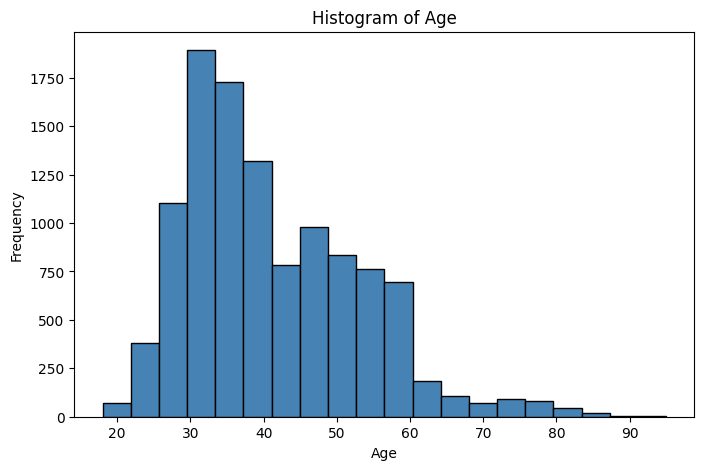

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

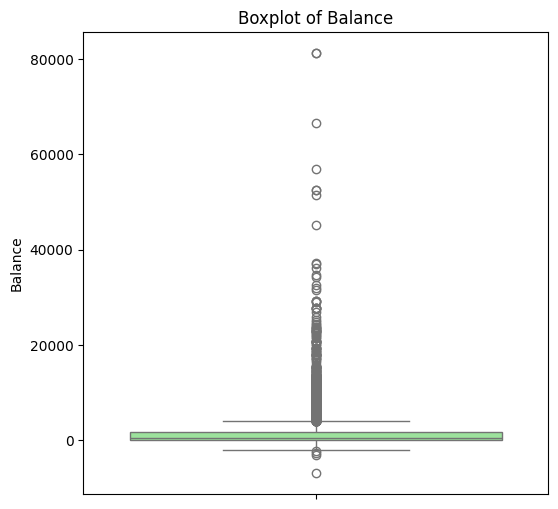

In [29]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=df['balance'], color='lightgreen')
plt.title('Boxplot of Balance')
plt.ylabel('Balance')
plt.show()

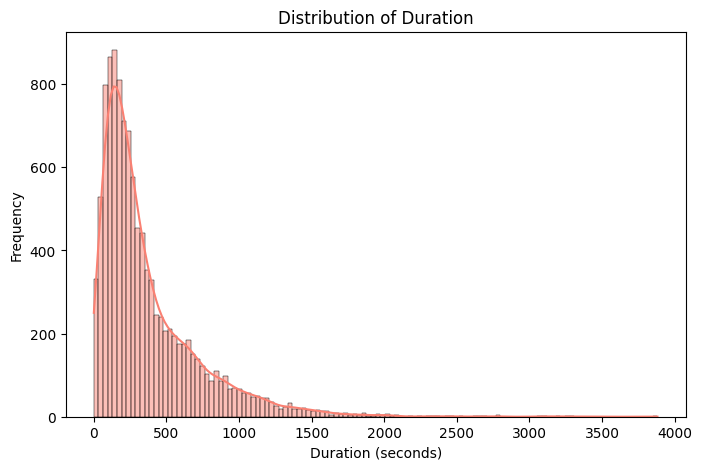

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df['duration'], kde=True, color='salmon')
plt.title('Distribution of Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

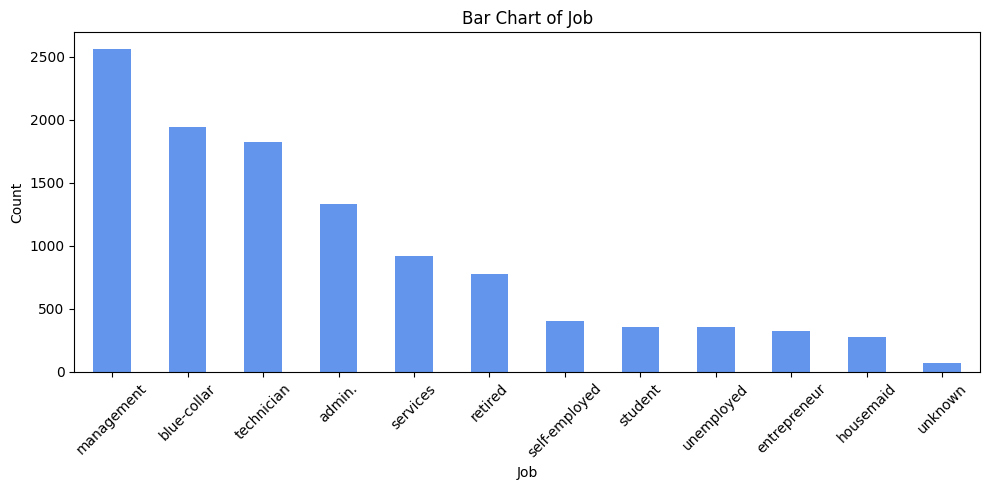

In [31]:
plt.figure(figsize=(10, 5))
df['job'].value_counts().plot(kind='bar', color='cornflowerblue')
plt.title('Bar Chart of Job')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

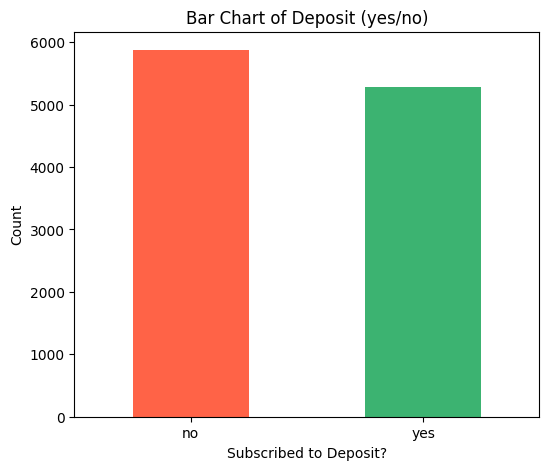

In [32]:
plt.figure(figsize=(6, 5))
df['deposit'].value_counts().plot(kind='bar', color=['tomato', 'mediumseagreen'])
plt.title('Bar Chart of Deposit (yes/no)')
plt.xlabel('Subscribed to Deposit?')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [33]:
print("""
Q1: Which preprocessing method was most effective for this dataset?
A:  Imputation was the most effective method because our dataset
    had no missing values, so no data was lost.
    
Q2: Which feature seems most related to deposit subscription?
A:  'duration' (call duration in seconds) is the most related feature.

Q3: What problems could appear if preprocessing is skipped?
A:  - Machine learning models will produce inaccurate results
    - Statistical calculations (mean, median) will be incorrect
    - Visualizations may be misleading or fail to render
    - Algorithms may crash when encountering missing values
    - Wrong data types cause errors in calculations
""")


Q1: Which preprocessing method was most effective for this dataset?
A:  Imputation was the most effective method because our dataset
    had no missing values, so no data was lost.

Q2: Which feature seems most related to deposit subscription?
A:  'duration' (call duration in seconds) is the most related feature.

Q3: What problems could appear if preprocessing is skipped?
A:  - Machine learning models will produce inaccurate results
    - Statistical calculations (mean, median) will be incorrect
    - Visualizations may be misleading or fail to render
    - Algorithms may crash when encountering missing values
    - Wrong data types cause errors in calculations

